# Jupyter - Day 7 - Section 002
# Even More Linear Regression

In the last few lectures, we have focused on linear regression, that is, fitting models of the form 

$$
Y =  \beta_0 +  \beta_1 X_1 +  \beta_2 X_2 + \cdots +  \beta_pX_p + \varepsilon
$$

In this lab, we will continue to use two different tools for linear regression. 
- [Scikit learn](https://scikit-learn.org/stable/index.html) is arguably the most used tool for machine learning in python 
- [Statsmodels](https://www.statsmodels.org) provides many of the statisitcial tests we've been learning in class

This lab will cover two ideas: 
- Categorical variables and how to represent them as dummy variables. 
- How to build interaction terms and pass them into your favorite model.

In [1]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import statsmodels.formula.api as smf

## More questions to ask of your model (Continued from last time)

### Q3: How well does the model fit?

This section talks about interpretation of $R^2$ and RSE, but is on slides only. 

### Q4: Making predictions



In [2]:
# you need the data from course website
advertising_df = pd.read_csv('../../../DataSets/Advertising.csv', index_col = 0)
# I need to sort the rows by TV to make plotting work better later 
advertising_df= advertising_df.sort_values(by=['TV'])
advertising_df.head()

,TV,Radio,Newspaper,Sales
131,0.7,39.6,8.7,1.6
156,4.1,11.6,5.7,3.2
79,5.4,29.9,9.4,5.3
57,7.3,28.1,41.4,5.5
127,7.8,38.9,50.6,6.6


In [3]:
# I want to just learn Sales using TV
est = smf.ols('Sales ~ TV', advertising_df).fit()
est.params

Intercept    7.032594
TV           0.047537
dtype: float64

In [4]:
# Here is a table giving us the CI and PI information 
alpha = 0.1
# alpha = 0.05
# alpha = 0.01
# alpha = 0.001
advert_summary = est.get_prediction(advertising_df).summary_frame(alpha=alpha)
advert_summary.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,7.065869,0.456216,6.311932,7.819806,1.628140,12.503598
1,7.227494,0.448345,6.486566,7.968422,1.791553,12.663435
2,7.289291,0.445348,6.553316,8.025267,1.854023,12.724559
3,7.379611,0.440981,6.650852,8.108370,1.945316,12.813907
4,7.403379,0.439835,6.676515,8.130244,1.969338,12.837421


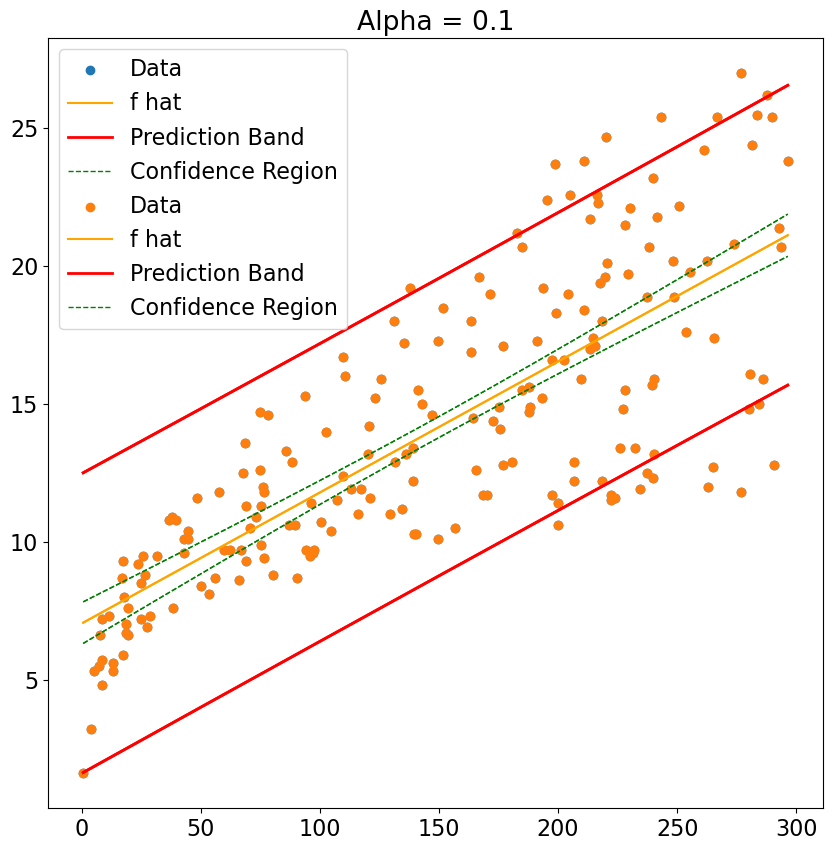

In [6]:
# And here is some code that will draw these beasts for us....
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams['font.size'] = 16


x = advertising_df['TV']
y = advertising_df['Sales']


# Plot the original data 
plt.scatter(x,y, label = 'Data')

# Plot the fitted values, AKA f_hat
# you can get this in two different places, same answer
# plt.plot(x,advert_summary['mean'], color = 'orange', label = 'f hat')
plt.plot(x,est.fittedvalues, color = 'orange', label = 'f hat')



plt.plot(x,advert_summary['obs_ci_lower'], 'r', lw=2, 
         label = r'Prediction Band')
plt.plot(x,advert_summary['obs_ci_upper'], 'r', lw=2)

plt.plot(x, advert_summary['mean_ci_lower'],'g--', lw=1, 
         label = r'Confidence Region')
plt.plot(x, advert_summary['mean_ci_upper'], 'g--', lw=1)

plt.title('Alpha = '+ str(alpha))



plt.legend()
plt.show()

##ANSWER##

### Code generating examples on slides
Removed from student version

In [6]:
##ANSWER##
Credit_df = pd.read_csv('../../../DataSets/Credit.csv', index_col = 0)
Credit_df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [7]:
##ANSWER##
est = smf.ols('Balance ~ Student', Credit_df).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,480.3694,23.434,20.499,0.000,434.300,526.439
Student[T.Yes],396.4556,74.104,5.350,0.000,250.771,542.140


## Playing with multi-level variables 


##ANSWER##

**INSTRUCTOR Warning: Much better updated version on the next slide deck, we didn't actually make it here for this lesson.**


### The wrong way

Ok, we're going to do this incorrectly to start. You pull in the `Auto` data set. You were so proud of yourself for remembering to fix the problems with the `horsepower` column that you conveniently forgot that the column with information about country of origin (`origin`) has a bunch of integers in it, representing:
- 1: `American`
- 2: `European`
- 3: `Japanese`.

In [7]:
Auto_df = pd.read_csv('../../../DataSets/Auto.csv')# find your data on course website
Auto_df = Auto_df.replace('?', np.nan)
Auto_df = Auto_df.dropna()
Auto_df.horsepower = Auto_df.horsepower.astype('int')


Auto_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

You then go on your merry way building the model 
$$
\texttt{mpg} = \beta_0 + \beta_1 \cdot \texttt{origin}. 
$$

In [8]:
from sklearn.linear_model import LinearRegression

X = Auto_df.origin.values
X = X.reshape(-1, 1)
y = Auto_df.mpg.values

regr = LinearRegression()

regr.fit(X,y)

print('beta_1 = ', regr.coef_[0])
print('beta_0 = ', regr.intercept_)

beta_1 =  5.4765474801914475
beta_0 =  14.811973615412462


In [9]:
##ANSWER##
# this is the statsmodels version, but i want to go use scikit learn
# because statsmodels hides the dummy variable stuff
est = smf.ols('mpg ~ origin', Auto_df).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,14.8120,0.716,20.676,0.000,13.404,16.220
origin,5.4765,0.405,13.531,0.000,4.681,6.272


&#9989; **<font color=red>Q:</font>** What does your model predict for each of the three types of cars? 

In [21]:
# Your code here

In [10]:
##ANSWER##
convertOrigin= {1: 'American', 2:'European', 3:'Japanese'}

# Prediction for "1" 
def prediction(n):
    return 14.8623 + 5.4967*n

for i in range(1,4):
    print(str(i), convertOrigin[i], ':', prediction(i))


1 American : 20.358999999999998
2 European : 25.8557
3 Japanese : 31.352399999999996


&#9989; **<font color=red>Q:</font>** Is it possible for your model to predict that both American and Japanese cars have `mpg` below European cars? 

Your answer here.

##ANSWER##
Not possible.  Because you have a linear model, they're either strictly decreasing (in order) or strictly increasing. Supposed to emphasize the fact that this is not the right way to train the model. 

### The right way

Ok, so you figure out your problem and decide to load in your data and fix the `origin` column to have names as entries.

In [12]:
convertOrigin= {1: 'American', 2:'European', 3:'Japanese'}

# This command swaps out each number n for convertOrigin[n], making it one of
# the three strings instead of an integer now.
Auto_df.origin = Auto_df.origin.apply(lambda n: convertOrigin[n])
Auto_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,American,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,American,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,American,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,American,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,American,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,American,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,European,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,American,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,American,ford ranger


Below is a quick code that automatically generates our dummy variables. Yay for not having to code that mess ourselves!

In [13]:
origin_dummies_df = pd.get_dummies(Auto_df.origin, prefix='origin')
origin_dummies_df

,origin_American,origin_European,origin_Japanese
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
392,True,False,False
393,False,True,False
394,True,False,False
395,True,False,False


&#9989; **<font color=red>Q:</font>** What is the interpretation of each column in the `origin_dummies_df` data frame?

*Your answer here*

I pass these new dummy variables into my `scikit-learn` linear regression model and get the following coefficients

In [14]:
X = origin_dummies_df.values
y = Auto_df.mpg

regr = LinearRegression()

regr.fit(X,y)

print('Coefs = ', regr.coef_)
print('Intercept = ', regr.intercept_)

Coefs =  [-5.9955451   1.57392668  4.42161842]
Intercept =  26.029014491872697


&#9989; **<font color=red>Q:</font>** Now what does your model predict for each of the three types of cars? 

In [ ]:
# Your code here

In [15]:
##ANSWER## 

print('American:')
print(regr.predict(((1, 0, 0),))[0])


print('European:')
print(regr.predict(((0, 1, 0),))[0])


print('Japanese:')
print(regr.predict(((0, 0, 1),))[0])


# Ok, so I was hoping the output would show that the function doesn't have to be 
# strictly increasing. So maybe just emphasize that it doesn't matter what order 
# these things were. 

American:
20.0334693877551
European:
27.602941176470587
Japanese:
30.450632911392404


#### Ooops

&#9989; **<font color=red>Q:</font>** Aw man, I didn't quite do what we said for the dummy variables in class. We talked about having only two dummy variables for a three level variable. Copy my code below here and fix it to have two variables instead of three. 
- Are your coefficients different now?
- Are your predictions for each of the three origins different now? 
- Does it matter which two levels you used for your dummy variables? 

In [ ]:
# Your code here

In [16]:
##ANSWER##
# Coefficients are different (in particular, there's a different number of
# them) but the prediction ends up the same.....
X = origin_dummies_df[['origin_American','origin_European']].values
y = Auto_df.mpg

regr = LinearRegression()

regr.fit(X,y)

print('Coefs = ', regr.coef_)
print('Intercept = ', regr.intercept_)

print('\n')

print('American:')
print(regr.predict(((1, 0),))[0])


print('European:')
print(regr.predict(((0, 1),))[0])


print('Japanese:')
print(regr.predict(((0, 0),))[0])

Coefs =  [-10.41716352  -2.84769173]
Intercept =  30.450632911392404


American:
20.033469387755105
European:
27.602941176470587
Japanese:
30.450632911392404


### Another right way

Ok, fine, I'll cave, I made you do it the hard way but you got to see how the innards worked, so maybe it's not all bad ;) 

First off, we can force `sklearn` to drop the first variable, so you don't have to do it manually every time. But you do need to know how to interpret the outputs!

In [26]:
# Even easier right way.... Note the only difference is the drop_first=True
origin_dummies_df = pd.get_dummies(Auto_df.origin, prefix='origin',drop_first=True)
print(origin_dummies_df.head())
X = origin_dummies_df
y = Auto_df.mpg
regr = LinearRegression()
regr.fit(X,y)

   origin_European  origin_Japanese
0            False            False
1            False            False
2            False            False
3            False            False
4            False            False


LinearRegression()

In `statsmodels`, it can automatically split up the categorical variables in a data frame, so it does the hard work for you. Note that here I'm plugging in the original `Auto_df` data frame, no processing of the categorical variables on my end at all. 

In [22]:
est = smf.ols('mpg ~ origin', Auto_df).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,20.0335,0.409,49.025,0.000,19.230,20.837
origin[T.European],7.5695,0.877,8.634,0.000,5.846,9.293
origin[T.Japanese],10.4172,0.828,12.588,0.000,8.790,12.044


&#9989; **<font color=red>Q:</font>** What is the model learned from the above printout? Be specific in terms of your dummy variables. 

Your answer here

In [25]:
##ANSWER##
origin_dummies_df = pd.get_dummies(Auto_df.origin, prefix='origin',drop_first=True)
X = origin_dummies_df
y = Auto_df.mpg
regr = LinearRegression()
regr.fit(X,y)

print('Coefs = ', regr.coef_)
print('Intercept = ', regr.intercept_)

print('y = ', round(regr.intercept_,2), 
      ' + ', round(regr.coef_[0],2), '*x_Euro + ', 
      round(regr.coef_[1],2), '*x_Japan',)

Coefs =  [ 7.56947179 10.41716352]
Intercept =  20.033469387755098
y =  20.03  +  7.57 *x_Euro +  10.42 *x_Japan




-----
### Congratulations, we're done!

Initially created by Dr. Liz Munch, Adapted by Dr. Mengsen Zhang, Michigan State University
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [6]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


<IPython.core.display.Javascript object>

Myfilename CMSE381-002-Lec07-EvenMoreLinReg-INSTRUCTOR.ipynb


CMSE381-002_Lec07_EvenMoreLinReg.ipynb


Validating Notebook ./CMSE381-002_Lec07_EvenMoreLinReg.ipynb


0